In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Seller performance analysis
# Loading datasets
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')

products_english = pd.read_csv('../data/product_category_name_translation.csv')
products = products.merge(products_english, on = 'product_category_name', how='inner')

print(f"Sellers: {sellers.columns}")
print(f'order_items: {order_items.columns}')
print(f'orders: {orders.columns}')

print(f"Orders: {len(orders):,}")
print(f"Order Items: {len(order_items):,}")
print(f"Sellers: {len(sellers):,}")
print(f"Reviews: {len(reviews):,}")

# Merging the datasets
seller_transactions = order_items.merge(
    orders[['order_id', 'order_status', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

print(f"After order merge: {len(seller_transactions):,}")

# Filtering on delivered orders only
seller_transactions = seller_transactions[
    seller_transactions['order_status'] == 'delivered'
    ].copy()

print(f"Delivered transactions: {len(seller_transactions):,}")

# Adding seller location
seller_transactions = seller_transactions.merge(
    sellers[['seller_id', 'seller_state', 'seller_city']],
    on='seller_id',
    how='left'
)

print(f"With seller location: {len(seller_transactions):,}")

# Adding product category
seller_transactions = seller_transactions.merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

# Adding review scores
seller_transactions = seller_transactions.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print(f"Final dataset: {len(seller_transactions):,}")
print(f"Unique Sellers: {seller_transactions['seller_id'].nunique():,}")

print(f"Missing seller ids: {seller_transactions['seller_id'].isna().sum():,}")
print(f"Missing price: {seller_transactions['price'].isna().sum():,}")
print(f"Missing Review Score: {seller_transactions['review_score'].isna().sum():,}")


Sellers: Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='str')
order_items: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
orders: Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')
Orders: 99,441
Order Items: 112,650
Sellers: 3,095
Reviews: 99,224
After order merge: 112,650
Delivered transactions: 110,197
With seller location: 110,197
Final dataset: 110,840
Unique Sellers: 2,970
Missing seller ids: 0
Missing price: 0
Missing Review Score: 827


In [4]:
# Seller concentration

# Calculating seller level metrics
seller_performance = seller_transactions.groupby('seller_id').agg({
    'order_id': 'nunique',
    'price': ['sum', 'mean'],
    'freight_value': 'mean',
    'review_score': 'mean',
    'product_id': 'nunique',
    'product_category_name_english': 'nunique'
}).reset_index()

# Flattening column names
seller_performance.columns = [
    'seller_id', 'num_orders', 'total_revenue', 'avg_price', 'avg_freight', 'avg_review', 'num_products', 'num_categories'
]

# Seller statistics
print(f"Total sellers: {len(seller_performance):,}")
print(f"Total revenue: BRL {seller_performance['total_revenue'].sum():,.2f}")
print(f"Total orders: {seller_performance['num_orders'].sum():,}")
print(f"Average orders per seller: {seller_performance['num_orders'].mean():.1f}")
print(f"Median orders per seller: {seller_performance['num_orders'].median():.0f}")

# Distribution stats
print(seller_performance['num_orders'].describe())

# Sorting by revenue
seller_performance = seller_performance.sort_values('total_revenue', ascending=False).reset_index(drop=True)

# Calculating cumulative metrics
seller_performance['revenue_rank'] = range(1, len(seller_performance)+1)
seller_performance['cumulative_revenue'] = seller_performance['total_revenue'].cumsum()
seller_performance['cumulative_revenue_pct'] = (
    seller_performance['cumulative_revenue']/seller_performance['total_revenue'].sum()*100
)

seller_performance['cumulative_orders'] = seller_performance['num_orders'].cumsum()
seller_performance['cumulative_orders_pct'] = (
    seller_performance['cumulative_orders']/seller_performance['num_orders'].sum()*100
)

# Finding 80/20 breakpoints
revenue_80_idx = (seller_performance['cumulative_revenue_pct'] <= 80).sum()
revenue_80_pct_sellers = revenue_80_idx/len(seller_performance)*100

orders_80_idx = (seller_performance['cumulative_orders_pct'] <= 80).sum()
orders_80_pct_sellers = orders_80_idx/len(seller_performance)*100

print("80/20 Analysis")
print(f"Top {revenue_80_pct_sellers:.2f}% of sellers drive 80% of revenue")
print(f"({revenue_80_idx:,} sellers out of {len(seller_performance):,})")
print(f"Top {orders_80_pct_sellers:.2f}% of sellers drive 80% of orders")
print(f"({orders_80_idx:,} sellers out of {len(seller_performance):,})")

# Additional concentration metrics
top1_revenue = seller_performance.head(1)['total_revenue'].sum()
top10_revenue = seller_performance.head(10)['total_revenue'].sum()
top100_revenue = seller_performance.head(100)['total_revenue'].sum()
total_revenue = seller_performance['total_revenue'].sum()

print("TOp seller concentration")
print(f"Top 1 seller:   BRL {top1_revenue:10,.0f} ({top1_revenue/total_revenue*100:.2f}%)")
print(f"Top 10 sellers: BRL {top10_revenue:10,.0f} ({top10_revenue/total_revenue*100:.2f}%)")
print(f"Top 100 sellers: BRL {top100_revenue:10,.0f} ({top100_revenue/total_revenue*100:.2f}%)")

# Top seller metrics
print("\n  Rank | Seller ID           | Orders | Revenue (BRL) | Avg Rating | Products | Avg Price")
print("  " + "-"*95)
top15 = seller_performance.head(15)
for idx, row in top15.iterrows():
    print(f"  {idx+1:4d} | "
          f"{row['seller_id'][:20]:<20} | "
          f"{row['num_orders']:6,} | "
          f"{row['total_revenue']:13,.0f} | "
          f"{row['avg_review']:10.2f} | "
          f"{row['num_products']:8,} | "
          f"{row['avg_price']:9,.2f}")

# Seller tiers
# Define tiers by revenue percentile
n_sellers = len(seller_performance)
seller_performance['tier'] = 'Bottom 50%'
seller_performance.loc[seller_performance['revenue_rank'] <= n_sellers * 0.5, 'tier'] = 'Middle 30%'
seller_performance.loc[seller_performance['revenue_rank'] <= n_sellers * 0.2, 'tier'] = 'Top 20%'

# Tier analysis
print(f"\n  Tier Analysis:")
for tier in ['Top 20%', 'Middle 30%', 'Bottom 50%']:
    tier_data = seller_performance[seller_performance['tier'] == tier]
    
    print(f"\n  {tier}:")
    print(f"    • Sellers: {len(tier_data):,}")
    print(f"    • Total Revenue: BRL {tier_data['total_revenue'].sum():,.0f} "
          f"({tier_data['total_revenue'].sum()/total_revenue*100:.1f}%)")
    print(f"    • Avg Revenue/Seller: BRL {tier_data['total_revenue'].mean():,.0f}")
    print(f"    • Median Revenue/Seller: BRL {tier_data['total_revenue'].median():,.0f}")
    print(f"    • Avg Orders/Seller: {tier_data['num_orders'].mean():.1f}")
    print(f"    • Avg Review Score: {tier_data['avg_review'].mean():.2f}")
    print(f"    • Avg Products/Seller: {tier_data['num_products'].mean():.1f}")

# Save seller performance data
seller_performance.to_csv('../outputs/seller_performance_analysis.csv', index=False)

# Key Insights:
# Revenue concentration: 17.91% of sellers drive 80% of the revenue (532 out of 2970), Top 20% of sellers 82.3% of revenue. Highly concentrated.
# Order concentration: Top 22.76% of sellers drive 80% of the orders (676 sellers). Slightly less concentrated than the revenue (some high-volume, low-price sellers)

# Top seller dominance:
# Top 1 seller: Driving 1.71% of total revenue with 1124 prders
# Top 10 sellers: Driving 13.28% of total revenue
# TOp 100 sellers: Driving 45.6% of total revenue.
# 100 sellers are 3.4% of marketplavce and they are driving nearly half the revenue. Extremely concentrated.

# From the rier analysis we see that 
# TOp 20% (594 sellers) are the professionals:
# 82.3% of the revenue with orders on average 126 per seller. 36 products per seller - diverse portfolio. 
# Avg revenue per seller is BRL 18,399 with a 4.09 average rating. These are serious, full-time sellers.
# Middle 30% (891 sellers) are the part-timers:
# 14.4% of revenue with orders on average 19 per seller. 9 products per seller - focused portfolio.
# Avg revenue per seller is BRL 2,146 with a 4.13 average rating. Side hustles or small businesses.
# Bottom 50% (1485 sellers) are the casuals:
# 3.3% of the revenue wuth orders on average 3.8 per seller. 2.7 products per seller.
# Avg revenue per seller is BRL 296 with 4.18 average rating. Most likely hobbyists, liquidating inventory, one-time sellers.

# We find a inverse rating-revenue relationship.
# Bottom 50% - 4.18 rating, middle 30% - 4.13 rating, top 20% - 4.09 rating.
# This can be attributed to 1. volume effect. Top sellers ship more -> more chances of problems
# 2. Small sample bias. Bottom sellers ship less orders -> easier to maintain good rating
# 3. Expectations: High volume sellers face higher customer expectations
# 4. Price-trading trade-off: TOp sellers may compete on price, sacrificing some quality

# Implications
# Platform concentration risk:
# 45% of the revenue is driven by 100 sellers
# If they leave there will be a massive revenue loss
# Platform should prioritize top 20% retention. Consider tiered commission structures (lower rates for top sellers to retain them)
# Two-speed marketplace:
# Top 20% vs Bottom 80%
# Top sellers are professionals (126 orders per seller). Bottom sellers are hobbyists (3.8 orders per seller)
# Different needs and different strategies
# Competitive dynamics
# Multi-seller products likely dominated by the top sellers. As they have 36 products on average. Likely high overlap in competitive categories.
# Likely price competition concentrated among top 20%
# Quality-revenue trade-off
# Top sellers have lower ratings but higher revenue
# A volume driven model and they can tolerate some quality issues or customers prefer selection/price over ratings

Total sellers: 2,970
Total revenue: BRL 13,279,836.59
Total orders: 97,819
Average orders per seller: 32.9
Median orders per seller: 7
count    2970.000000
mean       32.935690
std       105.407111
min         1.000000
25%         2.000000
50%         7.000000
75%        22.000000
max      1819.000000
Name: num_orders, dtype: float64
80/20 Analysis
Top 17.91% of sellers drive 80% of revenue
(532 sellers out of 2,970)
Top 22.76% of sellers drive 80% of orders
(676 sellers out of 2,970)
TOp seller concentration
Top 1 seller:   BRL    226,988 (1.71%)
Top 10 sellers: BRL  1,763,468 (13.28%)
Top 100 sellers: BRL  6,049,036 (45.55%)

  Rank | Seller ID           | Orders | Revenue (BRL) | Avg Rating | Products | Avg Price
  -----------------------------------------------------------------------------------------------
     1 | 4869f7a5dfa277a7dca6 |  1,124 |       226,988 |       4.14 |       94 |    197.72
     2 | 53243585a1d6dc264302 |    348 |       217,940 |       4.13 |       23 |    5

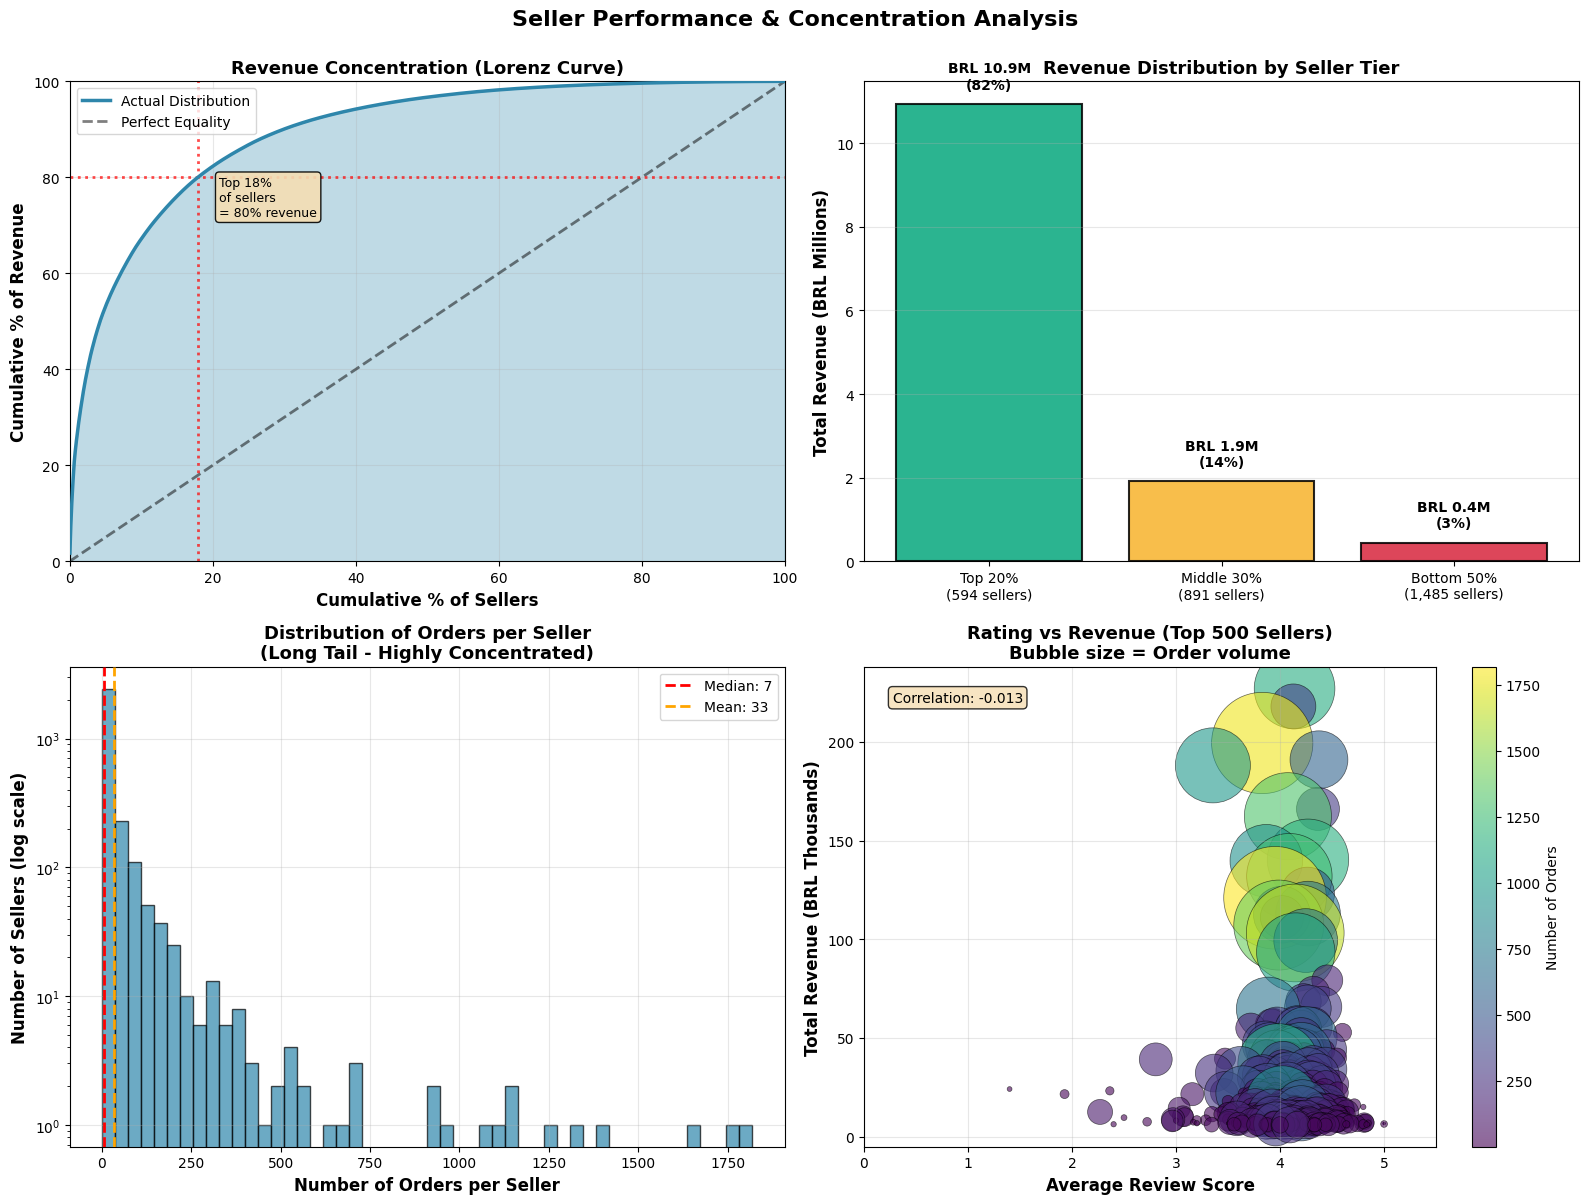

In [5]:
# Creating seller concentration visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Seller Performance & Concentration Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Cumulative revenue curve (Lorenz curve)
ax1 = axes[0, 0]
seller_pct = np.arange(1, len(seller_performance) + 1) / len(seller_performance) * 100
ax1.plot(seller_pct, seller_performance['cumulative_revenue_pct'], 
         linewidth=2.5, color='#2E86AB', label='Actual Distribution', zorder=3)
ax1.plot([0, 100], [0, 100], 'k--', alpha=0.5, linewidth=2, label='Perfect Equality')
ax1.axhline(80, color='red', linestyle=':', alpha=0.7, linewidth=2)
ax1.axvline(revenue_80_pct_sellers, color='red', linestyle=':', alpha=0.7, linewidth=2)
ax1.fill_between(seller_pct, 0, seller_performance['cumulative_revenue_pct'], 
                  alpha=0.3, color='#2E86AB')
ax1.set_xlabel('Cumulative % of Sellers', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative % of Revenue', fontsize=12, fontweight='bold')
ax1.set_title('Revenue Concentration (Lorenz Curve)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(alpha=0.3, zorder=0)
ax1.text(revenue_80_pct_sellers + 3, 72, 
         f'Top {revenue_80_pct_sellers:.0f}%\nof sellers\n= 80% revenue', 
         fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)

# 2. Revenue distribution by tier
ax2 = axes[0, 1]
tier_order = ['Top 20%', 'Middle 30%', 'Bottom 50%']
tier_revenue = [seller_performance[seller_performance['tier'] == t]['total_revenue'].sum() / 1e6 
                for t in tier_order]
tier_sellers = [len(seller_performance[seller_performance['tier'] == t]) 
                for t in tier_order]
colors = ['#06A77D', '#F7B32B', '#D7263D']
bars = ax2.bar(range(len(tier_revenue)), tier_revenue, color=colors, alpha=0.85, 
               edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(tier_revenue)))
ax2.set_xticklabels([f'{t}\n({n:,} sellers)' for t, n in zip(tier_order, tier_sellers)], fontsize=10)
ax2.set_ylabel('Total Revenue (BRL Millions)', fontsize=12, fontweight='bold')
ax2.set_title('Revenue Distribution by Seller Tier', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, zorder=0)

# Add value labels on bars
for bar, val in zip(bars, tier_revenue):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.3,
             f'BRL {val:.1f}M\n({val/sum(tier_revenue)*100:.0f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Orders per seller distribution
ax3 = axes[1, 0]
ax3.hist(seller_performance['num_orders'], bins=50, color='#2E86AB', 
         alpha=0.7, edgecolor='black', linewidth=1)
ax3.set_xlabel('Number of Orders per Seller', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Sellers (log scale)', fontsize=12, fontweight='bold')
ax3.set_title('Distribution of Orders per Seller\n(Long Tail - Highly Concentrated)', 
              fontsize=13, fontweight='bold')
ax3.set_yscale('log')
ax3.grid(alpha=0.3, zorder=0)

# Add statistics
median_orders = seller_performance['num_orders'].median()
mean_orders = seller_performance['num_orders'].mean()
p75_orders = seller_performance['num_orders'].quantile(0.75)
ax3.axvline(median_orders, color='red', linestyle='--', linewidth=2, 
            label=f'Median: {median_orders:.0f}', zorder=5)
ax3.axvline(mean_orders, color='orange', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_orders:.0f}', zorder=5)
ax3.legend(fontsize=10, loc='upper right')

# 4. Rating vs Revenue scatter (top 500 sellers)
ax4 = axes[1, 1]
plot_data = seller_performance.head(500).copy()
plot_data = plot_data.dropna(subset=['avg_review'])

scatter = ax4.scatter(plot_data['avg_review'], 
                      plot_data['total_revenue'] / 1000,
                      s=plot_data['num_orders'] * 3,
                      alpha=0.6, 
                      c=plot_data['num_orders'],
                      cmap='viridis',
                      edgecolors='black',
                      linewidth=0.5)
ax4.set_xlabel('Average Review Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Total Revenue (BRL Thousands)', fontsize=12, fontweight='bold')
ax4.set_title('Rating vs Revenue (Top 500 Sellers)\nBubble size = Order volume', 
              fontsize=13, fontweight='bold')
ax4.set_xlim(0, 5.5)
ax4.grid(alpha=0.3, zorder=0)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Number of Orders', fontsize=10)

# Add correlation
valid_data = plot_data.dropna(subset=['avg_review', 'total_revenue'])
if len(valid_data) > 0:
    corr = valid_data[['avg_review', 'total_revenue']].corr().iloc[0, 1]
    ax4.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
             transform=ax4.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             verticalalignment='top')

plt.tight_layout()
plt.savefig('../outputs/images/seller_concentration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# The above chat shows:
# 1. Revenue concentration (Lorenz Curve):
# Massive inequality - the curve is far from diagonal. Top 18% of sellers drive 80% of revenue. The curve shoots up steeply at the left -> top sellers dominate
# Area between the curves the Gini Coefficient (high inequality)
# The market place is more concentrated.
# 2. Revenue distribution by tier:
# Green bar towers over others - top 20%, Yello bar is modest - Middle 30%, Red bar barely visible - Bottom 50%. 
# 594 sellers (20%) earn more than 2376 sellers (80%) combined
# Bottom 50% collectively earn less than top 3 sellers
# 3. Distribution of orders per seller:
# Log tail: Median 7 orders, mean 33 orders. Log scale shows extreme skew - more sellers clustered at left
# Hockey stick: ~ 500 sellers have 1-5 orders, ~200 sellers have 6-20 orders then rapid drop-off. One seller at 1819 orders
# 4. Rating vs Revenue:
#  Correlation is -0.013 - No relationship between rating and revenue.
#  High revenue sellers scattered across all rating ranges
# The blob patterns : Giant cluster at 4.0 - 5.0 rating, mostly low revenue. Some large bubble (high volume) at lower ratings. Top revenue sellers have ratings between 3.3 and 4.4
# These indicate ratings don't drive revenue in this marketplace
# Price/selection matter more than rating. Search algorithm might not prioritize ratings heavily. 
# Customers tolerate mediocre ratings if price is right. Volume sellers sacrifice quality for scale.

# Implications:
# Platform Strategy: Focus on top 20%. Do not lose them. Add VIP seller program, lower commission rates, dedicated support.
# Seller segmentation: TOp 20% - need advanced analytics, bulk tools, priority support. Pricing Strategy: Volume-based commissions.

In [6]:
# Multi-Seller Competitive Dynamics

# Identify multi-seller products
product_seller_counts = seller_transactions.groupby('product_id')['seller_id'].nunique()
multi_seller_products = product_seller_counts[product_seller_counts >= 2].index

print(f"Total products in dataset: {len(product_seller_counts):,}")
print(f"Multi-seller products: {len(multi_seller_products):,}")
print(f"Percentage of catalog: {len(multi_seller_products)/len(product_seller_counts)*100:.1f}%")
print(f"Single-seller products: {(product_seller_counts == 1).sum():,} ({(product_seller_counts == 1).sum()/len(product_seller_counts)*100:.1f}%)")

# Filter to multi-seller transactions
multi_seller_data = seller_transactions[
    seller_transactions['product_id'].isin(multi_seller_products)
].copy()

print(f"\n Multi-Seller Market Size:")
print(f"Transactions in multi-seller products: {len(multi_seller_data):,}")
print(f"Revenue from multi-seller products: BRL {multi_seller_data['price'].sum():,.2f}")
print(f"% of total revenue: {multi_seller_data['price'].sum()/seller_transactions['price'].sum()*100:.1f}%")

# Calculate price variation by product
price_variation = multi_seller_data.groupby('product_id').agg({
    'price': ['mean', 'std', 'min', 'max', 'count'],
    'seller_id': 'nunique',
    'product_category_name_english': 'first'
}).reset_index()

price_variation.columns = ['product_id', 'avg_price', 'std_price', 'min_price', 
                           'max_price', 'num_transactions', 'num_sellers', 'category']

# Coefficient of variation
price_variation['cv'] = price_variation['std_price'] / price_variation['avg_price']
price_variation['price_range'] = price_variation['max_price'] - price_variation['min_price']
price_variation['price_range_pct'] = (price_variation['price_range'] / price_variation['min_price'] * 100)

# Remove products with zero std (all same price)
price_variation = price_variation[price_variation['std_price'] > 0].copy()

print(f"\n Price Dispersion Analysis:")
print(f"Products with price variation: {len(price_variation):,}")
print(f"Average price CV: {price_variation['cv'].mean():.3f}")
print(f"Median price CV: {price_variation['cv'].median():.3f}")
print(f"Average price range: {price_variation['price_range_pct'].mean():.1f}%")
print(f"Max price range: {price_variation['price_range_pct'].max():.1f}%")

# Distribution of CV
print(f"\n Price Variation Distribution:")
print(f"CV < 0.05 (tight competition):   {(price_variation['cv'] < 0.05).sum():,} products ({(price_variation['cv'] < 0.05).sum()/len(price_variation)*100:.1f}%)")
print(f"CV 0.05-0.15 (moderate):         {((price_variation['cv'] >= 0.05) & (price_variation['cv'] < 0.15)).sum():,} products ({((price_variation['cv'] >= 0.05) & (price_variation['cv'] < 0.15)).sum()/len(price_variation)*100:.1f}%)")
print(f"CV 0.15-0.30 (loose competition): {((price_variation['cv'] >= 0.15) & (price_variation['cv'] < 0.30)).sum():,} products ({((price_variation['cv'] >= 0.15) & (price_variation['cv'] < 0.30)).sum()/len(price_variation)*100:.1f}%)")
print(f"CV > 0.30 (high dispersion):     {(price_variation['cv'] >= 0.30).sum():,} products ({(price_variation['cv'] >= 0.30).sum()/len(price_variation)*100:.1f}%)")


# Sort by price dispersion
price_variation = price_variation.sort_values('cv', ascending=False)

print(f"\n Top 15 most competitive products (Highest Price Variance):")
print("\n  Sellers | Trans | Avg Price | Min-Max Range    | CV    | Category")
print("  " + "-"*85)
for idx, row in price_variation.head(15).iterrows():
    cat_str = str(row['category'])[:25] if pd.notna(row['category']) else 'Unknown'
    print(f"  {row['num_sellers']:7d} | "
          f"{row['num_transactions']:5d} | "
          f"BRL {row['avg_price']:7,.2f} | "
          f"{row['min_price']:6,.2f} - {row['max_price']:7,.2f} | "
          f"{row['cv']:5.3f} | "
          f"{cat_str}")

print(f"\n TOp 15 least competitive products (Lowest Price Variance):")
print("\n  Sellers | Trans | Avg Price | Min-Max Range    | CV    | Category")
print("  " + "-"*85)
for idx, row in price_variation.tail(15).iterrows():
    cat_str = str(row['category'])[:25] if pd.notna(row['category']) else 'Unknown'
    print(f"  {row['num_sellers']:7d} | "
          f"{row['num_transactions']:5d} | "
          f"BRL {row['avg_price']:7,.2f} | "
          f"{row['min_price']:6,.2f} - {row['max_price']:7,.2f} | "
          f"{row['cv']:5.3f} | "
          f"{cat_str}")

# Category analysis
category_competition = multi_seller_data.groupby('product_category_name_english').agg({
    'product_id': 'nunique',
    'price': ['mean', 'std'],
    'seller_id': 'nunique',
    'order_id': 'count'
}).reset_index()

category_competition.columns = ['category', 'num_products', 'avg_price', 'std_price', 'num_sellers', 'num_orders']
category_competition['cv'] = category_competition['std_price'] / category_competition['avg_price']
category_competition = category_competition.sort_values('num_products', ascending=False)

print(f"\n Top 15 categories with most multi-seller competition:")
print("\n  Category                       | Products | Sellers | Orders | Avg Price | CV")
print("  " + "-"*90)
for idx, row in category_competition.head(15).iterrows():
    cat_str = str(row['category'])[:30] if pd.notna(row['category']) else 'Unknown'
    cv_str = f"{row['cv']:4.2f}" if pd.notna(row['cv']) and row['cv'] < 99 else "N/A"
    print(f"  {cat_str:<30} | "
          f"{row['num_products']:8,} | "
          f"{row['num_sellers']:7,} | "
          f"{row['num_orders']:6,} | "
          f"BRL {row['avg_price']:6,.2f} | "
          f"{cv_str}")

# Save results
price_variation.to_csv('../outputs/multi_seller_price_variation.csv', index=False)

Total products in dataset: 32,216
Multi-seller products: 1,189
Percentage of catalog: 3.7%
Single-seller products: 31,027 (96.3%)

 Multi-Seller Market Size:
Transactions in multi-seller products: 13,935
Revenue from multi-seller products: BRL 1,765,615.42
% of total revenue: 13.3%

 Price Dispersion Analysis:
Products with price variation: 1,151
Average price CV: 0.086
Median price CV: 0.061
Average price range: 24.9%
Max price range: 688.2%

 Price Variation Distribution:
CV < 0.05 (tight competition):   464 products (40.3%)
CV 0.05-0.15 (moderate):         498 products (43.3%)
CV 0.15-0.30 (loose competition): 163 products (14.2%)
CV > 0.30 (high dispersion):     26 products (2.3%)

 Top 15 most competitive products (Highest Price Variance):

  Sellers | Trans | Avg Price | Min-Max Range    | CV    | Category
  -------------------------------------------------------------------------------------
        2 |     2 | BRL   28.11 |   6.33 -   49.89 | 1.096 | sports_leisure
        2 | 

In [30]:
# Key Insights
# Small but significant market:
# 3.7% of total catalog has multi sellers. 1189 products but 13,935 transactions. Revenue driven is BRL 1.77M (13.3% of total)
# As small number of products are driving more revenue these are likely high demand products
# Price competition is moderate.
# 40% have tight competition, 43% have moderate competition, only 2.3% have high competition.
# Sellers match price closely.
# Price Variance:
# The highest price variance is sports_leisure but the CV = 1.096 with 688% price range. Likely data issue.
# Computers, watches have high price varince - quality/branded products vs less quality/non-branded products
# Zero variance: is observed in furniture, health_beauty, telephony. Likely price matching or manufacture MAP
# Competitive products:
# Health_beauty: 142 products, 144 sellers. Many SKUs, differentiated products. High CV.
# Watches_gifts: 120 products, 36 sellers. Moderate CV.
# Computer_accessories: 117 products, 49 sellers. moderate CV.

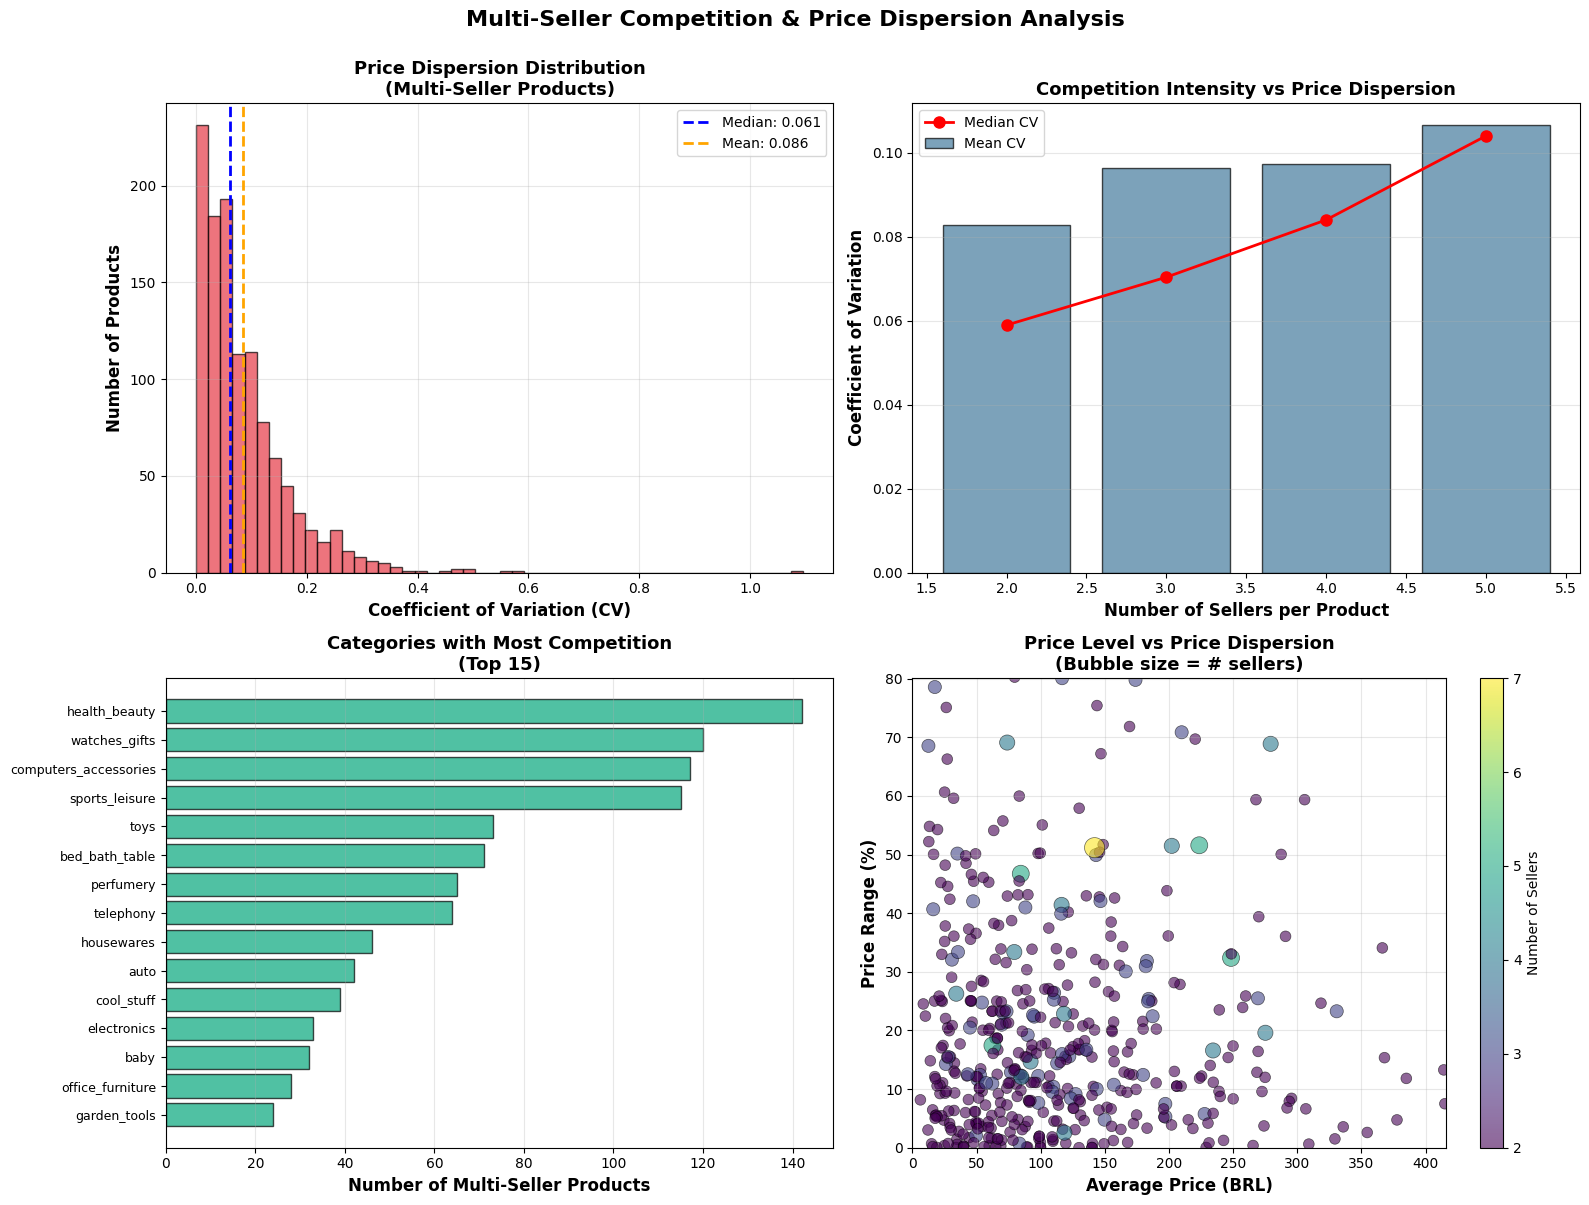

In [7]:
# Creating multi-seller competition visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Multi-Seller Competition & Price Dispersion Analysis', 
             fontsize=16, fontweight='bold', y=1.00)

# 1. Distribution of Coefficient of Variation
ax1 = axes[0, 0]
ax1.hist(price_variation['cv'], bins=50, color='#E63946', alpha=0.7, edgecolor='black')
ax1.axvline(price_variation['cv'].median(), color='blue', linestyle='--', 
            linewidth=2, label=f'Median: {price_variation["cv"].median():.3f}')
ax1.axvline(price_variation['cv'].mean(), color='orange', linestyle='--', 
            linewidth=2, label=f'Mean: {price_variation["cv"].mean():.3f}')
ax1.set_xlabel('Coefficient of Variation (CV)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Products', fontsize=12, fontweight='bold')
ax1.set_title('Price Dispersion Distribution\n(Multi-Seller Products)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, zorder=0)

# 2. Number of sellers vs price variation
ax2 = axes[0, 1]
seller_cv = price_variation.groupby('num_sellers')['cv'].agg(['mean', 'median', 'count'])
seller_cv = seller_cv[seller_cv['count'] >= 5]  # Only groups with 5+ products

x = seller_cv.index
ax2.bar(x, seller_cv['mean'], alpha=0.7, color='#457B9D', edgecolor='black', 
        label='Mean CV')
ax2.plot(x, seller_cv['median'], 'ro-', linewidth=2, markersize=8, 
         label='Median CV')
ax2.set_xlabel('Number of Sellers per Product', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coefficient of Variation', fontsize=12, fontweight='bold')
ax2.set_title('Competition Intensity vs Price Dispersion', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, axis='y', zorder=0)

# 3. Category-level competition
ax3 = axes[1, 0]
top_cats = category_competition.head(15)
y_pos = np.arange(len(top_cats))
ax3.barh(y_pos, top_cats['num_products'], color='#06A77D', alpha=0.7, edgecolor='black')
ax3.set_yticks(y_pos)
ax3.set_yticklabels([str(c)[:25] if pd.notna(c) else 'Unknown' for c in top_cats['category']], 
                     fontsize=9)
ax3.set_xlabel('Number of Multi-Seller Products', fontsize=12, fontweight='bold')
ax3.set_title('Categories with Most Competition\n(Top 15)', 
              fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3, axis='x', zorder=0)
ax3.invert_yaxis()

# 4. Price range vs average price
ax4 = axes[1, 1]
# Sample for readability
plot_sample = price_variation.sample(min(500, len(price_variation)), random_state=42)
scatter = ax4.scatter(plot_sample['avg_price'], 
                      plot_sample['price_range_pct'],
                      s=plot_sample['num_sellers']*30,
                      alpha=0.6,
                      c=plot_sample['num_sellers'],
                      cmap='viridis',
                      edgecolors='black',
                      linewidth=0.5)
ax4.set_xlabel('Average Price (BRL)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Price Range (%)', fontsize=12, fontweight='bold')
ax4.set_title('Price Level vs Price Dispersion\n(Bubble size = # sellers)', 
              fontsize=13, fontweight='bold')
ax4.set_xlim(0, plot_sample['avg_price'].quantile(0.95))
ax4.set_ylim(0, plot_sample['price_range_pct'].quantile(0.95))
ax4.grid(alpha=0.3, zorder=0)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Number of Sellers', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/images/multi_seller_competition_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# From the plot above
# The price dispersion distribution has a massive left skew. Indicating most competition is tight translating to narrow price band. 
# A Few products have price variation indicating quality tiers.
# Competition Intensity vs Price dispersion:
# More Sellers = More price variance.
# From the plot we see that the median slopes up consistently. Counter intuitive: More competition leads to wider price variance not narrower. Interesting finding. 
# Possible explanations: quality differences, market segmentation (premium vs discounted).
# Categories with most competition:
# Health_beauty dominates: Extremely competitive, many SKUs, branda
# Electronics and tech products cluster together
# Discretionary categories (toys, sports, watches) also has competition.
# Price level vs price dispersion
# Most products cluster at low prices + low variance

In [8]:
# Geographic Analysis

# Load customer data and location dataset
customers = pd.read_csv('../data/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')

print(f"Customers: {len(customers):,}")
print(f"Geolocation: {len(geolocation):,}")

# We already have seller data with seller location. Lets add customer state into it. Before that lets merge seller_transactions with orders to get customer id
seller_transactions_cust = seller_transactions.merge(
    orders,
    on='order_id',
    how='left'
)

seller_transactions_geo = seller_transactions_cust.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)

print(f"Total transactions: {len(seller_transactions_geo):,}")
print(f"Transactions with customer state: {seller_transactions_geo['customer_state'].notna().sum():,}")
print(f"Transactions with seller state: {seller_transactions_geo['seller_state'].notna().sum():,}")


# Quick state codes
print(f"Customer states: {seller_transactions_geo['customer_state'].nunique()}")
print(f"Seller states: {seller_transactions_geo['seller_state'].nunique()}")


Customers: 99,441
Geolocation: 1,000,163
Total transactions: 110,840
Transactions with customer state: 110,840
Transactions with seller state: 110,840
Customer states: 27
Seller states: 22


In [9]:
# Customer demand by state

# Aggregate by customer state
customer_state_analysis = seller_transactions_geo.groupby('customer_state').agg({
    'order_id': 'count',
    'price': ['sum', 'mean'],
    'freight_value': 'mean',
    'customer_id': 'nunique',
    'seller_id': 'nunique'
}).reset_index()

customer_state_analysis.columns= ['state', 'num_orders', 'total_revenue', 'avg_order_value', 'avg_freight', 'num_customers', 'num_sellers']

# Sort by revenue
customer_state_analysis = customer_state_analysis.sort_values('total_revenue', ascending=False)

# Calculate percentages
total_orders = customer_state_analysis['num_orders'].sum()
total_revenue = customer_state_analysis['total_revenue'].sum()

customer_state_analysis['pct_orders'] = (customer_state_analysis['num_orders']/total_orders * 100)
customer_state_analysis['pct_revenue'] = (customer_state_analysis['total_revenue']/total_revenue * 100)

# Cumulative
customer_state_analysis['cumulative_revenue_pct'] = (
    customer_state_analysis['total_revenue'].cumsum() / total_revenue * 100
)

print(f"Total states with customers: {len(customer_state_analysis)}")
print(f"Total orders: {total_orders:,}")
print(f"Total revenue: BRL {total_revenue:,.2f}")

# Top states
print("\n  State | Orders  | Revenue (BRL) | % Revenue | Cum % | Avg Order | Customers")
print("  " + "-"*90)
for idx, row in customer_state_analysis.head(15).iterrows():
    print(f"  {row['state']:5s} | "
          f"{row['num_orders']:7,} | "
          f"{row['total_revenue']:13,.0f} | "
          f"{row['pct_revenue']:8.2f}% | "
          f"{row['cumulative_revenue_pct']:5.1f}% | "
          f"BRL {row['avg_order_value']:6,.0f} | "
          f"{row['num_customers']:6,}")

# 80/20 analysis
revenue_80_states = (customer_state_analysis['cumulative_revenue_pct'] <= 80).sum()
revenue_80_pct = revenue_80_states / len(customer_state_analysis) * 100

print(f"\nGeographic Concentration:")
print(f"Top {revenue_80_pct:.0f}% of states = 80% of revenue")
print(f"({revenue_80_states} states out of {len(customer_state_analysis)})")

# Top 3 states
top3_revenue = customer_state_analysis.head(3)['total_revenue'].sum()
top3_pct = top3_revenue / total_revenue * 100
print(f"  • Top 3 states = {top3_pct:.1f}% of revenue")

top5_revenue = customer_state_analysis.head(5)['total_revenue'].sum()
top5_pct = top5_revenue / total_revenue * 100
print(f"  • Top 5 states = {top5_pct:.1f}% of revenue")

Total states with customers: 27
Total orders: 110,840
Total revenue: BRL 13,279,836.59

  State | Orders  | Revenue (BRL) | % Revenue | Cum % | Avg Order | Customers
  ------------------------------------------------------------------------------------------
  SP    |  46,714 |     5,093,380 |    38.35% |  38.4% | BRL    109 | 40,501
  RJ    |  14,224 |     1,766,257 |    13.30% |  51.7% | BRL    124 | 12,350
  MG    |  12,995 |     1,558,668 |    11.74% |  63.4% | BRL    120 | 11,354
  RS    |   6,182 |       732,421 |     5.52% |  68.9% | BRL    118 |  5,345
  PR    |   5,673 |       668,891 |     5.04% |  73.9% | BRL    118 |  4,923
  SC    |   4,112 |       508,579 |     3.83% |  77.8% | BRL    124 |  3,546
  BA    |   3,703 |       495,417 |     3.73% |  81.5% | BRL    134 |  3,256
  DF    |   2,381 |       298,493 |     2.25% |  83.8% | BRL    125 |  2,080
  GO    |   2,297 |       285,780 |     2.15% |  85.9% | BRL    124 |  1,957
  ES    |   2,236 |       269,231 |     2.03% | 

In [ ]:
#GEOGRAPHIC CONCENTRATION:
#1. EXTREME CONCENTRATION - SÃO PAULO DOMINATES:
#The Top 3 States:
#SP (São Paulo): 38.4% of total revenue! (BRL 5.09M)
#46,714 orders (42% of total)
#40,501 customers
#São Paulo alone = more than next 3 states combined!
#RJ (Rio de Janeiro): 13.3% (BRL 1.77M)
#14,224 orders
#12,350 customers
#MG (Minas Gerais): 11.7% (BRL 1.56M)
#12,995 orders
#11,354 customers
#Combined: SP + RJ + MG = 63.4% of total revenue!

#2. THE 80/20 RULE (Actually 80/22!):
#Geographic 80/20:
#Top 22% of states (6 states) = 80% of revenue
#Top 6: SP, RJ, MG, RS, PR, SC = 77.8% of revenue
#Remaining 21 states = only 22% of revenue
#This is even more concentrated than seller concentration!

#Seller 80/20: Top 17.9% = 80% revenue
#Geographic 80/20: Top 22% = 80% revenue

#3. NORTH vs SOUTH DISPARITY:
#High-Revenue States (Avg Order > BRL 140):
#PE (Pernambuco): BRL 144 avg
#CE (Ceará): BRL 154 avg
#PA (Pará): BRL 165 avg
#MT (Mato Grosso): BRL 147 avg
#MA (Maranhão): BRL 146 avg
#These are NORTHERN/NORTHEAST states with:
#HIGHER avg order value (BRL 144-165 vs BRL 109-124 in South)
#But LOWER order volume
#Why?
#Shipping costs included? Higher freight to remote regions
#Wealthier customers? Willing to pay premium for delivery
#Selection bias: Only high-value purchases justify shipping
#Fewer orders: 805-1,758 orders vs 46,714 in SP

#Southeast (SP, RJ, MG) Pattern:
#LOWER avg order (BRL 109-124)
#MASSIVE volume (74,000+ orders)
#Dense urban markets, competitive pricing

#4. THE REGIONAL DIVIDE:
#Southeast Powerhouse (SP, RJ, MG, ES):
#65.4% of revenue (4 states)
#Dense population, urban centers
#Low avg freight (local sellers)
#South (RS, PR, SC):
#14.4% of revenue (3 states)
#Developed region, good logistics
#Northeast + North:
#~15% of revenue (many states)
#Higher freight, lower volume
#Opportunity for growth?

In [10]:
# Seller location patterns

# Aggregate by seller state
seller_state_analysis = seller_transactions_geo.groupby('seller_state').agg({
    'order_id': 'count',
    'price': ['sum', 'mean'],
    'seller_id': 'nunique',
    'customer_id': 'nunique'
}).reset_index()

seller_state_analysis.columns = ['state', 'num_orders', 'total_revenue', 'avg_order_value', 'num_sellers', 'num_customers']

seller_state_analysis = seller_state_analysis.sort_values('total_revenue', ascending=False)

# Calculate percentages
seller_state_analysis['pct_revenue'] = (
    seller_state_analysis['total_revenue'] / total_revenue * 100
)

# Top states by seller activity
print("\n  State | Sellers | Orders  | Revenue (BRL) | % Revenue | Avg Order")
print("  " + "-"*80)
for idx, row in seller_state_analysis.head(15).iterrows():
    print(f"  {row['state']:5s} | "
          f"{row['num_sellers']:7,} | "
          f"{row['num_orders']:7,} | "
          f"{row['total_revenue']:13,.0f} | "
          f"{row['pct_revenue']:8.2f}% | "
          f"BRL {row['avg_order_value']:6,.0f}")

# Seller concentration
top_seller_state = seller_state_analysis.iloc[0]
print(f"\nSeller Concentration:")
print(f"Top seller state: {top_seller_state['state']}")
print(f"{top_seller_state['num_sellers']:,} sellers ({top_seller_state['num_sellers']/seller_state_analysis['num_sellers'].sum()*100:.1f}%)")
print(f"BRL {top_seller_state['total_revenue']:,.0f} ({top_seller_state['pct_revenue']:.1f}%)")

top3_seller_states = seller_state_analysis.head(3)
top3_sellers = top3_seller_states['num_sellers'].sum()
total_sellers = seller_state_analysis['num_sellers'].sum()
print(f"Top 3 states have {top3_sellers:,} sellers ({top3_sellers/total_sellers*100:.1f}%)")



  State | Sellers | Orders  | Revenue (BRL) | % Revenue | Avg Order
  --------------------------------------------------------------------------------
  SP    |   1,769 |  79,078 |     8,548,956 |    64.38% | BRL    108
  PR    |     335 |   8,563 |     1,240,516 |     9.34% | BRL    145
  MG    |     236 |   8,648 |       981,274 |     7.39% | BRL    113
  RJ    |     163 |   4,702 |       823,390 |     6.20% | BRL    175
  SC    |     184 |   4,014 |       615,030 |     4.63% | BRL    153
  RS    |     125 |   2,180 |       375,866 |     2.83% | BRL    172
  BA    |      18 |     626 |       278,047 |     2.09% | BRL    444
  DF    |      30 |     885 |        94,912 |     0.71% | BRL    107
  PE    |       9 |     445 |        91,164 |     0.69% | BRL    205
  GO    |      39 |     509 |        64,886 |     0.49% | BRL    127
  ES    |      22 |     364 |        46,942 |     0.35% | BRL    129
  MA    |       1 |     403 |        36,221 |     0.27% | BRL     90
  CE    |      12 | 

In [11]:
# Cross-state transactions

# Same state vs different state
seller_transactions_geo['same_state'] = (
    seller_transactions_geo['seller_state'] == seller_transactions_geo['customer_state']
)

same_state_count = seller_transactions_geo['same_state'].sum()
total_count = len(seller_transactions_geo)
cross_state_count = total_count - same_state_count

same_state_pct = same_state_count / total_count * 100
cross_state_pct = cross_state_count / total_count * 100

print(f"Same-state transactions: {same_state_count:,} ({same_state_pct:.1f}%)")
print(f"Cross-state transactions: {cross_state_count:,} ({cross_state_pct:.1f}%)")

# Revenue comparison
same_state_revenue = seller_transactions_geo[seller_transactions_geo['same_state']]['price'].sum()
cross_state_revenue = seller_transactions_geo[~seller_transactions_geo['same_state']]['price'].sum()

print(f"\n Revenue Split:")
print(f"Same-state revenue: BRL {same_state_revenue:,.2f} ({same_state_revenue/total_revenue*100:.1f}%)")
print(f"Cross-state revenue: BRL {cross_state_revenue:,.2f} ({cross_state_revenue/total_revenue*100:.1f}%)")

# Average freight comparison
same_state_freight = seller_transactions_geo[seller_transactions_geo['same_state']]['freight_value'].mean()
cross_state_freight = seller_transactions_geo[~seller_transactions_geo['same_state']]['freight_value'].mean()

print(f"\n Shipping Cost Impact:")
print(f"Avg freight (same-state): BRL {same_state_freight:.2f}")
print(f"Avg freight (cross-state): BRL {cross_state_freight:.2f}")
print(f"Difference: BRL {cross_state_freight - same_state_freight:+.2f} ({(cross_state_freight/same_state_freight - 1)*100:+.1f}%)")

# Most common state pairs
state_pairs = seller_transactions_geo[~seller_transactions_geo['same_state']].groupby(
    ['seller_state', 'customer_state']
).size().reset_index(name='num_orders')

state_pairs = state_pairs.sort_values('num_orders', ascending=False)

# Top 10 cross-state seller-customer pairs:
print("\n  Seller - Customer | Orders")
print("  " + "-"*35)
for idx, row in state_pairs.head(10).iterrows():
    print(f"  {row['seller_state']:5s} - {row['customer_state']:5s}      | {row['num_orders']:6,}")

Same-state transactions: 40,089 (36.2%)
Cross-state transactions: 70,751 (63.8%)

 Revenue Split:
Same-state revenue: BRL 4,152,340.39 (31.3%)
Cross-state revenue: BRL 9,127,496.20 (68.7%)

 Shipping Cost Impact:
Avg freight (same-state): BRL 13.45
Avg freight (cross-state): BRL 23.62
Difference: BRL +10.17 (+75.6%)

  Seller - Customer | Orders
  -----------------------------------
  SP    - RJ         |  9,458
  SP    - MG         |  8,627
  SP    - RS         |  4,157
  SP    - PR         |  3,628
  PR    - SP         |  3,366
  MG    - SP         |  2,918
  SP    - SC         |  2,721
  SP    - BA         |  2,639
  SP    - GO         |  1,671
  SP    - ES         |  1,627


In [ ]:
# Critical findings

# Geographical dynamics:
# Sao Paulo is the marketplacehub
# Seller concentration is extreme 59.6% of all sellers and generates 64.4% of revenue.
# TOp 3 states (SP, PR, MG) combined has 78.8% of sellers
# This translates to Sao Paulo is the supply center of Brazil's e-commerce. Most sellers are based in SP metro area. Creates a hub-and-spoke distribution model.

# Looking at the customer-seller mismatch -> Customer demand in SP is 38.4% of revenue, Seller supply in SP is 64.4% of revenue. SP exports to the rest of Brazil.
# Rio de Janerio (RJ) -> CUstomer side 2nd largest market, seller side 4th place. Net importer. RJ customers by from SP sellers.

# Cross-state dominance
# 63.8% of transactions are cross-state. 68.7% of revenue is cross-state. Only 36% of tramsactions are same state.
# This is a national market place. Not local.
# Shipping cost impact: 
# Same state freight - BRL 13.45, Cross-state freight - BRL 23.62. This is 76% higher for cross-state
# Customers are willing to pay 76% more in shipping for access to SP sellers.
# Two explanations: SP has better selection/prices, Local sellers insufficient supply.

In [12]:
# Geographic Pricing Patterns

# Price comparison by region
# Average price by customer state 
print("\n  State | Avg Price | Avg Freight | Total Cost | # Orders")
print("  " + "-"*70)

price_by_state = seller_transactions_geo.groupby('customer_state').agg({
    'price': 'mean',
    'freight_value': 'mean',
    'order_id': 'count'
}).reset_index()

price_by_state['total_cost'] = price_by_state['price'] + price_by_state['freight_value']
price_by_state = price_by_state.sort_values('price', ascending=False)

for idx, row in price_by_state.head(15).iterrows():
    print(f"  {row['customer_state']:5s} | "
          f"BRL {row['price']:6,.2f} | "
          f"BRL {row['freight_value']:6,.2f} | "
          f"BRL {row['total_cost']:7,.2f} | "
          f"{row['order_id']:7,}")

# Regional pricing tiers
# Define regions
southeast = ['SP', 'RJ', 'MG', 'ES']
south = ['RS', 'PR', 'SC']
northeast = ['BA', 'PE', 'CE', 'MA', 'RN', 'PB', 'PI', 'AL', 'SE']
north = ['PA', 'AM', 'AP', 'TO', 'RO', 'AC', 'RR']
centerwest = ['DF', 'GO', 'MT', 'MS']

# Function to classify region
def classify_region(state):
    if state in southeast: return 'Southeast'
    elif state in south: return 'South'
    elif state in northeast: return 'Northeast'
    elif state in north: return 'North'
    elif state in centerwest: return 'Center-West'
    else: return 'Other'

seller_transactions_geo['region'] = seller_transactions_geo['customer_state'].apply(classify_region)

# Regional analysis
regional_pricing = seller_transactions_geo.groupby('region').agg({
    'price': 'mean',
    'freight_value': 'mean',
    'order_id': 'count',
    'customer_id': 'nunique'
}).reset_index()

regional_pricing['total_cost'] = regional_pricing['price'] + regional_pricing['freight_value']
regional_pricing = regional_pricing.sort_values('total_cost', ascending=False)

print("\n  Region        | Avg Price | Avg Freight | Total Cost | Orders  | Customers")
print("  " + "-"*85)
for idx, row in regional_pricing.iterrows():
    print(f"  {row['region']:13s} | "
          f"BRL {row['price']:6,.2f} | "
          f"BRL {row['freight_value']:6,.2f} | "
          f"BRL {row['total_cost']:7,.2f} | "
          f"{row['order_id']:7,} | "
          f"{row['customer_id']:8,}")

# Price elasticity proxy: Do high-freight states buy less?
# Correlation between freight and order volume
state_freight_demand = seller_transactions_geo.groupby('customer_state').agg({
    'freight_value': 'mean',
    'order_id': 'count',
    'price': 'mean'
}).reset_index()

correlation = state_freight_demand[['freight_value', 'order_id']].corr().iloc[0, 1]
print(f"Correlation (freight vs order volume): {correlation:.3f}")

if correlation < -0.3:
    print(f"Strong negative: High freight REDUCES demand")
elif correlation < 0:
    print(f"Weak negative: Freight has modest negative impact")
else:
    print(f"Positive/neutral: Freight doesn't deter demand")

# Same-state vs cross-state pricing
print(f"\n PRICING STRATEGY BY TRANSACTION TYPE:")

same_state_stats = seller_transactions_geo[seller_transactions_geo['same_state']].agg({
    'price': 'mean',
    'freight_value': 'mean'
})

cross_state_stats = seller_transactions_geo[~seller_transactions_geo['same_state']].agg({
    'price': 'mean',
    'freight_value': 'mean'
})

print(f"\n  Same-State Transactions:")
print(f"Avg price: BRL {same_state_stats['price']:.2f}")
print(f"Avg freight: BRL {same_state_stats['freight_value']:.2f}")
print(f"Total cost: BRL {same_state_stats['price'] + same_state_stats['freight_value']:.2f}")

print(f"\n  Cross-State Transactions:")
print(f"Avg price: BRL {cross_state_stats['price']:.2f}")
print(f"Avg freight: BRL {cross_state_stats['freight_value']:.2f}")
print(f"Total cost: BRL {cross_state_stats['price'] + cross_state_stats['freight_value']:.2f}")

freight_premium = cross_state_stats['freight_value'] - same_state_stats['freight_value']
total_cost_diff = (cross_state_stats['price'] + cross_state_stats['freight_value']) - (same_state_stats['price'] + same_state_stats['freight_value'])

print(f"\n  Impact:")
print(f"Freight premium (cross-state): BRL {freight_premium:+.2f} ({freight_premium/same_state_stats['freight_value']*100:+.1f}%)")
print(f"Total cost difference: BRL {total_cost_diff:+.2f}")

# Do cross-state customers pay LOWER product prices?
price_diff = cross_state_stats['price'] - same_state_stats['price']
print(f"\n  Price Offset Strategy:")
if price_diff < -2:
    print(f"Cross-state product prices are BRL {abs(price_diff):.2f} LOWER")
    print(f"Sellers offset high freight with lower product prices!")
else:
    print(f"Product prices similar (BRL {price_diff:+.2f})")
    print(f"Customers bear full freight cost")



  State | Avg Price | Avg Freight | Total Cost | # Orders
  ----------------------------------------------------------------------
  PB    | BRL 191.95 | BRL  43.06 | BRL  235.01 |     587
  AL    | BRL 183.43 | BRL  35.77 | BRL  219.20 |     431
  AC    | BRL 175.07 | BRL  40.05 | BRL  215.11 |      91
  RO    | BRL 167.34 | BRL  41.33 | BRL  208.67 |     273
  AP    | BRL 165.12 | BRL  34.16 | BRL  199.28 |      81
  PA    | BRL 164.89 | BRL  35.54 | BRL  200.43 |   1,061
  PI    | BRL 161.80 | BRL  39.08 | BRL  200.88 |     524
  RN    | BRL 157.09 | BRL  35.71 | BRL  192.80 |     523
  TO    | BRL 156.14 | BRL  37.44 | BRL  193.57 |     310
  CE    | BRL 154.04 | BRL  32.73 | BRL  186.77 |   1,431
  RR    | BRL 153.42 | BRL  43.09 | BRL  196.51 |      46
  SE    | BRL 150.86 | BRL  36.57 | BRL  187.44 |     375
  MT    | BRL 146.61 | BRL  27.98 | BRL  174.60 |   1,040
  MA    | BRL 145.60 | BRL  38.43 | BRL  184.03 |     805
  PE    | BRL 143.86 | BRL  32.62 | BRL  176.48 |   1,75

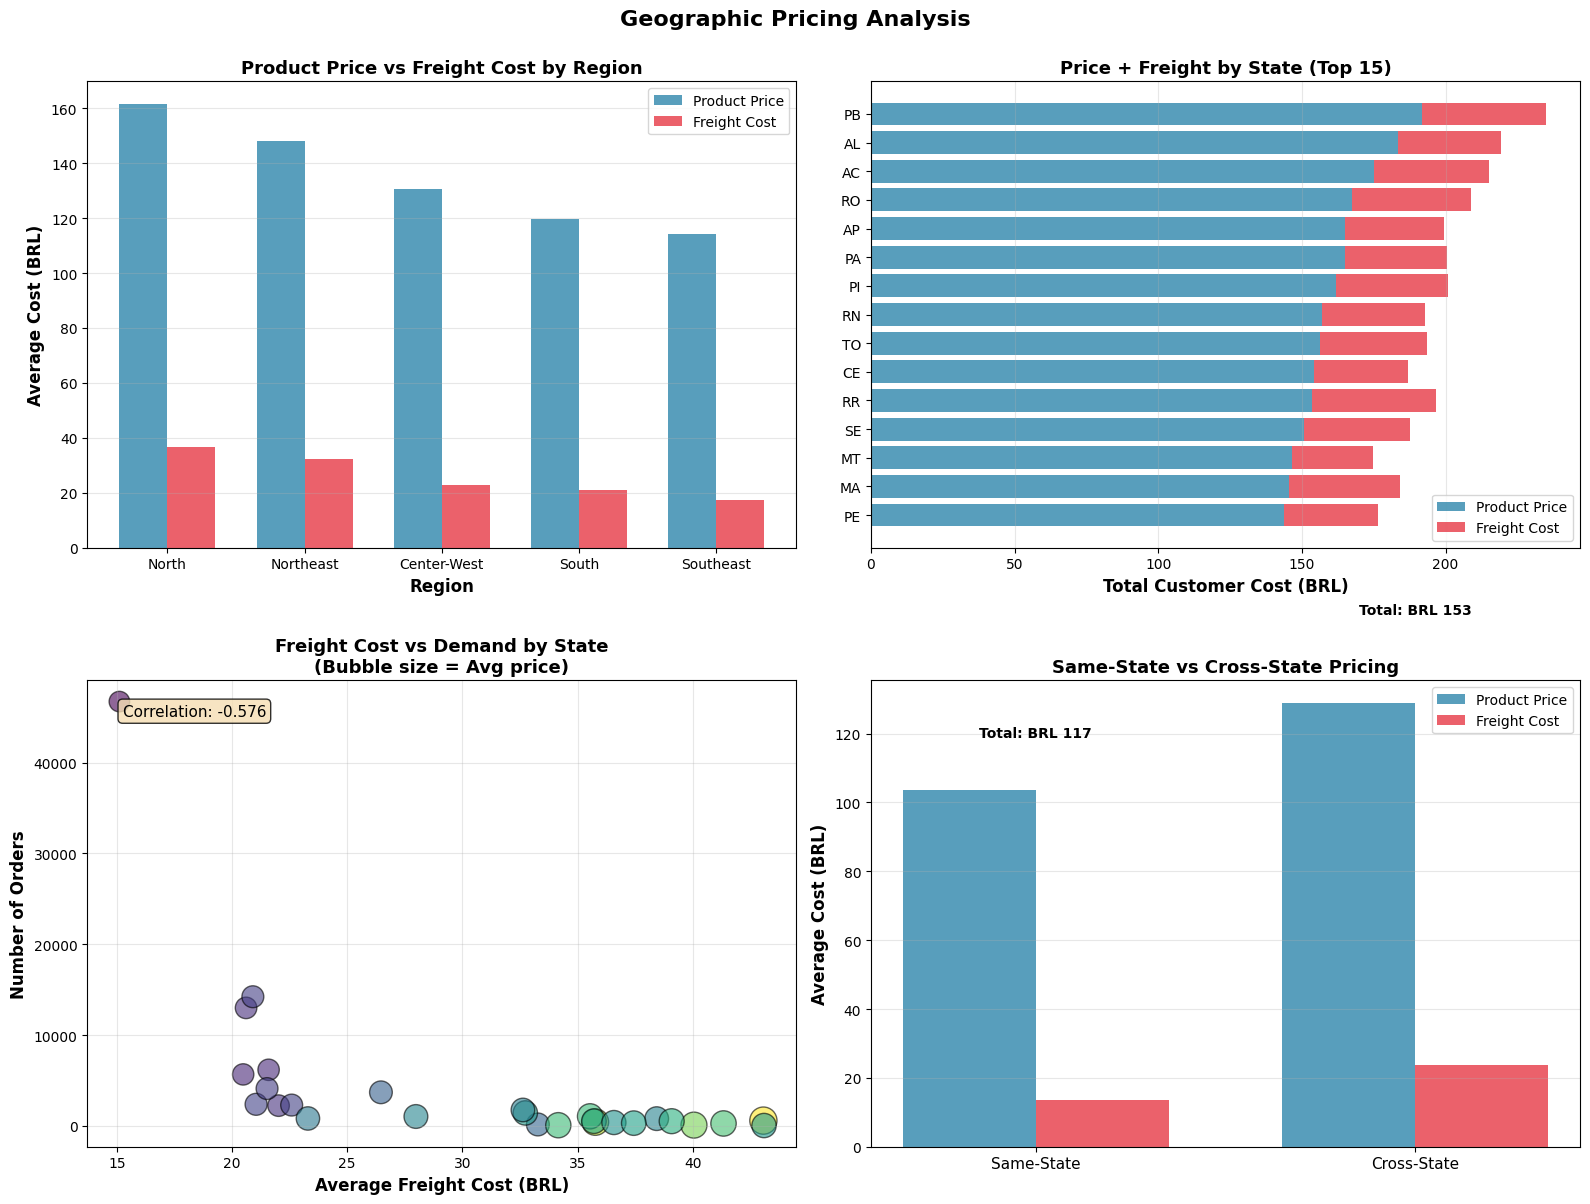

In [13]:
# Creating geographic pricing visualizations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Geographic Pricing Analysis', fontsize=16, fontweight='bold', y=1.00)

# 1. Regional pricing comparison
ax1 = axes[0, 0]
x = np.arange(len(regional_pricing))
width = 0.35

price_bars = ax1.bar(x - width/2, regional_pricing['price'], width, 
                     label='Product Price', color='#2E86AB', alpha=0.8)
freight_bars = ax1.bar(x + width/2, regional_pricing['freight_value'], width,
                       label='Freight Cost', color='#E63946', alpha=0.8)

ax1.set_xlabel('Region', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Cost (BRL)', fontsize=12, fontweight='bold')
ax1.set_title('Product Price vs Freight Cost by Region', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(regional_pricing['region'], fontsize=10)
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# 2. Total customer cost by state (top 15)
ax2 = axes[0, 1]
top_states = price_by_state.head(15)
y_pos = np.arange(len(top_states))

# Stack price + freight
ax2.barh(y_pos, top_states['price'], color='#2E86AB', alpha=0.8, label='Product Price')
ax2.barh(y_pos, top_states['freight_value'], left=top_states['price'],
         color='#E63946', alpha=0.8, label='Freight Cost')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_states['customer_state'], fontsize=10)
ax2.set_xlabel('Total Customer Cost (BRL)', fontsize=12, fontweight='bold')
ax2.set_title('Price + Freight by State (Top 15)', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3, axis='x')
ax2.invert_yaxis()

# 3. Freight vs Order Volume (scatter)
ax3 = axes[1, 0]
ax3.scatter(state_freight_demand['freight_value'], 
           state_freight_demand['order_id'],
           s=state_freight_demand['price']*2,
           alpha=0.6,
           c=state_freight_demand['price'],
           cmap='viridis',
           edgecolors='black',
           linewidth=1)

ax3.set_xlabel('Average Freight Cost (BRL)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Orders', fontsize=12, fontweight='bold')
ax3.set_title('Freight Cost vs Demand by State\n(Bubble size = Avg price)', 
              fontsize=13, fontweight='bold')
ax3.grid(alpha=0.3)

# Add correlation text
ax3.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
         transform=ax3.transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         verticalalignment='top')

# 4. Same-state vs Cross-state comparison
ax4 = axes[1, 1]
categories = ['Same-State', 'Cross-State']
price_vals = [same_state_stats['price'], cross_state_stats['price']]
freight_vals = [same_state_stats['freight_value'], cross_state_stats['freight_value']]

x_cat = np.arange(len(categories))
width = 0.35

ax4.bar(x_cat - width/2, price_vals, width, label='Product Price', 
        color='#2E86AB', alpha=0.8)
ax4.bar(x_cat + width/2, freight_vals, width, label='Freight Cost',
        color='#E63946', alpha=0.8)

ax4.set_ylabel('Average Cost (BRL)', fontsize=12, fontweight='bold')
ax4.set_title('Same-State vs Cross-State Pricing', fontsize=13, fontweight='bold')
ax4.set_xticks(x_cat)
ax4.set_xticklabels(categories, fontsize=11)
ax4.legend()
ax4.grid(alpha=0.3, axis='y')

# Add annotations
for i, (p, f) in enumerate(zip(price_vals, freight_vals)):
    total = p + f
    ax4.text(i, total + 2, f'Total: BRL {total:.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/images/geographic_pricing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Geographic pricing patterns:
# Freight is a major demand barrier. 
# The chart shows that the correlation is -0.576 strong negative. States with freight 40+ have < 1000 orders. States with 20 freight have 10,000 - 15,000 orders.
# Freight cost is more important than product price for demand
# Customers are freight sensitive, not just price-sensitive
# Free shipping thresholds would unlock remote markets
# Cross state customers pay 30% more.
# Same state: Product - BRL 103.58, Freight - BRL 13.45, Total - BRL 117.02
# Cross state: Product - BRL 129.01, Freight - BRL 23.62, Total - BRL 152.62

# Cross state customers pay Higher Product Prices, not just Freight. 
# H1: Selection Bias: Same state - low value commodity purchase, cross state - higher value speciality items. Customers only order cross-state if product unavailable locally
# H2: Freight inclusive pricing: Some sellers include Freight in product price, Makes freight appear lower, product price higher, But total cost is accurate
# H3: Premium Sellers: Cross state sellers have better products, Higher quality/brands command premium. 

# Pricing Strategy Implications:
# Free Shipping Threshold Strategy: Correlation -0.576
# Free shipping on orders > BRL 150.
# With free shipping it is expected that the quantity orderd will be increased (from the correlation). This will offset the freight costs.

# Dynamic Freight Pricing:
# Current Freight is fixed based on distance
# Freight is 76% higher cross-state, deterring purchases.
# Distance based subsidies.
# Model:
# Base freight: Actual cost
# Subsidy: Max(0, Freight - BRL 15)
# Customer pays: Min(Freight, BRL 15 + 50% of excess)
# Example - North State (BRL 37 freight):
# Current: Customer pays BRL 37
# With subsidy: Customer pays BRL 15 + (37-15)×0.5 = BRL 26
# Platform subsidy: BRL 11
# Impact:
# Reduce North freight from BRL 37 → BRL 26 (-30%)
# Total cost: BRL 198 → BRL 187 (-5.5%)
# Expected demand increase: +30% (based on -0.576 correlation)
# Subsidy cost: BRL 11 × 2,026 orders × 1.3 = BRL 29K
# Revenue gain: BRL 328K × 0.3 = BRL 98K
# Net profit: +BRL 69K